# EME convergence for a bent anisotropic waveguide (LiNbO₃)

Lithium niobate (LiNbO₃) is a key material in integrated photonics due to its large electro-optic coefficient and wide transparency window. However, it is a **uniaxial crystal**: its permittivity is described by a tensor, not a scalar. This has important consequences when the waveguide is bent.

In this notebook we:
1. Run an **FDTD** simulation of a 180° LiNbO₃ waveguide bend to obtain a reference transmittance.
2. Run **EME** simulations of the same bend with increasing numbers of cells.
3. Show that a **single EME cell overestimates transmission** and explain the physical origin.
4. Demonstrate **convergence of EME to the FDTD result** as the cell count increases.

For an introduction to the EME solver in Tidy3D see the [EME solver tutorial](https://www.flexcompute.com/tidy3d/examples/notebooks/EMESolver/) and the [bent waveguides with EME](https://www.flexcompute.com/tidy3d/examples/notebooks/EMEBends/) notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.web as web
from tidy3d.plugins.mode import ModeSolver

td.config.logging.level = "ERROR"

## Physics Background: Why Anisotropy Complicates Bent-Waveguide EME

### The Rotating Permittivity Tensor

LiNbO₃ is **uniaxial**: it has one extraordinary index $n_e \approx 2.14$ along the optic (c) axis and an ordinary index $n_o \approx 2.21$ along the other two directions (at 1.55 µm). In the material API, `Zelmon1997(1)` places the extraordinary axis along the **global $y$** direction (index `2` would place it along $z$). The lab-frame tensor used here is therefore

$$
\varepsilon_\text{lab} = \begin{pmatrix} n_o^2 & 0 & 0 \\ 0 & n_e^2 & 0 \\ 0 & 0 & n_o^2 \end{pmatrix}
\qquad \text{(optic axis along } y\text{)} .
$$

The key point is that the optic axis lies **in the plane of the bend** (the $x$–$y$ plane). In a **straight** waveguide propagating along $x$ the tensor is constant — modes are quasi-TE / quasi-TM and propagate without cross-coupling. However, in a **bent** waveguide (ring in the $x$–$y$ plane) the local propagation direction rotates by an angle $\phi$ as the wave travels around the bend. From the co-moving frame the effective tensor becomes

$$
\varepsilon_\text{local}(\phi) = R_z(\phi)^\top \, \varepsilon_\text{lab} \, R_z(\phi) .
$$

Because the optic axis lies in the rotation ($x$–$y$) plane and $n_o \neq n_e$, this rotation produces **off-diagonal terms** that grow with $\phi$. The local eigenmodes therefore evolve continuously as the wave travels — the quasi-TE and quasi-TM modes of the bent waveguide mix along the propagation path.

### Consequence for EME

EME divides the waveguide into $N$ cells and matches eigenmodes at each cell boundary. At every interface the two adjacent mode bases are slightly misaligned due to the incremental tensor rotation — generating partial **back-reflections** and **mode conversion**.

| EME cells | Physical picture |
|-----------|------------------|
| **1** | Entire 180° bend is one uniform section. No inter-cell interfaces → **no reflections from tensor rotation** → transmission is overestimated. |
| **few** | Tensor rotation is approximated as a staircase; dominant back-reflection is captured. |
| **many** | Staircase finely resolves the continuous rotation → **converges to FDTD**. |

The loss mechanism is not geometric bending loss (negligible at $r = 5$ µm for this waveguide) but **polarization-state evolution** driven by the rotating anisotropy.

In [2]:
# ── Simulation parameters ──────────────────────────────────────────────────
wavelength = 1.55  # free-space wavelength (µm)
freq0 = td.C_0 / wavelength

radius = 5.0  # bend radius (µm)
width = 0.6  # waveguide width (µm)
thickness = 0.4  # waveguide thickness (µm)

num_modes = 5  # number of modes in mode solvers
target_neff = 1.65  # target effective index for mode search
plane_size = (9.0, 9.0)  # cross-section window size (µm)
min_steps_per_wvl = 30  # grid resolution (steps per wavelength)

# ── Materials ───────────────────────────────────────────────────────────────
SiO2 = td.material_library["SiO2"]["Palik_Lossless"]
# (1): extraordinary (optic) axis along global y — in the bend plane, the
# orientation-sensitive case. Use (2) to place the optic axis along z instead.
LiNbO3 = td.material_library["LiNbO3"]["Zelmon1997"](1)

## Step 1 — FDTD Reference Simulation

We model the 180° bend as a **full ring** in the FDTD simulation:

- **Geometry**: outer [Cylinder](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Cylinder.html) minus inner cylinder (LiNbO₃ annulus on SiO₂).
- **Source**: [ModeSource](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSource.html) at the bottom of the ring `(0, −r, 0)`, launching in the +x direction with a negative bend radius (the center of curvature is on the +y side of the source).
- **Monitor**: [ModeMonitor](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeMonitor.html) at the top of the ring `(0, +r, 0)`, measuring the amplitudes of all guided modes travelling in the −x direction (i.e., those that have propagated 180° around the bend).
- **Boundaries**: [Absorber](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.Absorber.html) on ±x to suppress re-entry of any radiation that escapes the open side of the ring; [PML](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.PML.html) on ±y, ±z.

The bend curvature is encoded in the [ModeSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.ModeSpec.html) via `bend_radius` and `bend_axis`.

The source and monitor sort their modes with `ModeSortSpec(sort_key="fill_fraction_box", bounding_box=core_box)`: in a bent, anisotropic waveguide the default ordering (by effective index) does not reliably put the guided fundamental first, so we instead rank modes by the fraction of their intensity that falls inside a box wrapping the core. The most core-confined (guided) mode then lands at `mode_index = 0` regardless of polarization or tensor-rotation mixing. (`fill_fraction_box` ranks by **confinement, not polarization** — the polarization is verified separately.)

In [3]:
def build_fdtd_bend(
    radius=5.0,
    width=0.6,
    thickness=0.4,
    num_modes=10,
    target_neff=1.65,
    freq0=td.C_0 / 1.55,
    core_medium=LiNbO3,
    background_medium=SiO2,
    plane_size=(9.0, 9.0),
    min_steps_per_wvl=30,
    mode_index=0,
):
    """Build an FDTD simulation of a 180-degree LiNbO3 waveguide bend.

    The geometry is a ring (annular cylinder) with a ModeSource at the
    bottom and a ModeMonitor at the top, measuring 180-degree transmission.
    """
    wavelength = td.C_0 / freq0
    cross_sec = (0, plane_size[0], plane_size[1])  # cross-section for mode planes

    core_box_src = td.Box(center=(0, -radius, 0), size=(0, width, thickness))
    core_box_mon = td.Box(center=(0, radius, 0), size=(0, width, thickness))

    sort_spec_src = td.ModeSortSpec(sort_key="fill_fraction_box", bounding_box=core_box_src)
    sort_spec_mon = td.ModeSortSpec(sort_key="fill_fraction_box", bounding_box=core_box_mon)

    # Bend mode specs
    # Source at bottom (0, -r, 0) going in +x: center of curvature is at +y → negative radius
    # Monitor at top  (0, +r, 0) receiving in -x: center of curvature is at -y → positive radius
    mode_spec_src = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=-radius,
        bend_axis=1,
        num_pml=(12, 12),
        sort_spec=sort_spec_src,
        precision="double",
    )
    mode_spec_mon = td.ModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=(12, 12),
        sort_spec=sort_spec_mon,
        precision="double",
    )

    # Ring geometry: outer cylinder minus inner cylinder
    outer = td.Cylinder(center=(0, 0, 0), radius=radius + width / 2, length=thickness, axis=2)
    inner = td.Cylinder(center=(0, 0, 0), radius=radius - width / 2, length=thickness, axis=2)
    ring = td.Structure(geometry=outer - inner, medium=core_medium)

    # Simulation domain — asymmetric: source side open, far side has extra room
    ring_outer = radius + width / 2
    x_min, x_max = -wavelength, ring_outer + 2 * wavelength
    sim_size = (x_max - x_min, 2 * (radius + width + 2 * wavelength), plane_size[1])
    sim_center = ((x_min + x_max) / 2, 0, 0)

    source = td.ModeSource(
        center=(0, -radius, 0),
        size=cross_sec,
        source_time=td.GaussianPulse(freq0=freq0, fwidth=0.1 * freq0),
        mode_spec=mode_spec_src,
        direction="+",
        mode_index=mode_index,
    )

    # Field monitor in the z=0 plane for visualization
    field_xy = td.FieldMonitor(
        center=(0, 0, 0),
        size=(td.inf, td.inf, 0),
        freqs=[freq0],
        name="field_xy",
    )

    # Mode amplitude monitor at the output (top of the ring)
    mode_out = td.ModeMonitor(
        center=(0, radius, 0),
        size=cross_sec,
        freqs=[freq0],
        name="mode_out",
        mode_spec=mode_spec_mon,
    )

    return td.Simulation(
        size=sim_size,
        center=sim_center,
        structures=[ring],
        sources=[source],
        monitors=[field_xy, mode_out],
        medium=background_medium,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        run_time=0.6e-12,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.absorber(num_layers=160),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
    )

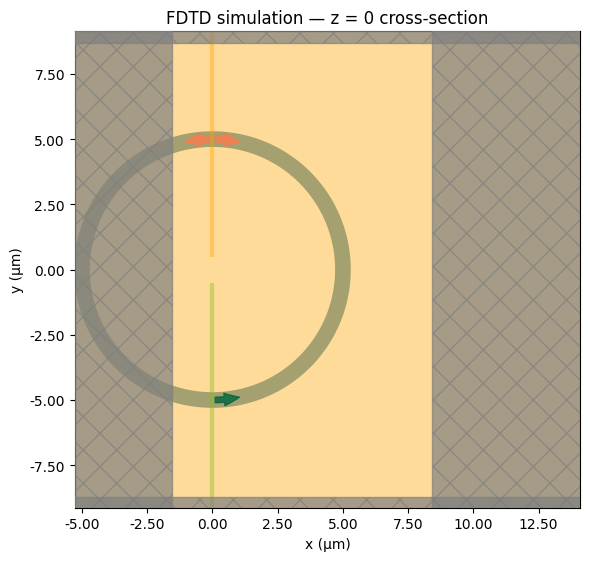

In [4]:
fdtd_sim_test = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    plane_size=plane_size,
    min_steps_per_wvl=min_steps_per_wvl,
    mode_index=0,  # fundamental quasi-TE bend mode
)

fig, ax = plt.subplots(figsize=(6, 6))
fdtd_sim_test.plot(z=0, ax=ax)
ax.set_title("FDTD simulation — z = 0 cross-section")
plt.tight_layout()
plt.show()

### Mode Solver Verification

Before running the FDTD, we use the [ModeSolver](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.mode.ModeSolver.html) plugin on the source plane to confirm that the fundamental bend mode is the one being excited.

In [5]:
ms = ModeSolver(
    simulation=fdtd_sim_test,
    mode_spec=fdtd_sim_test.sources[0].mode_spec,
    plane=fdtd_sim_test.sources[0].geometry,
    freqs=fdtd_sim_test.sources[0].source_time.freq0,
)

ms_data = web.run(ms)

18:00:50 -03 Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=442911;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=932229;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\taskId]8;;\]8;id=442911;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\=]8;;\]8;id=653959;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\mo]8;;\]8;id=442911;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\-5e3caacc-ec46-]8;;\
             ]8;id=442911;https://tidy3d.simulation.cloud/workbench?taskId=mo-5e3caacc-ec46-4d43-9fd9-91cb96ac5e90\4d43-9fd9-91cb96ac5e90']8;;\.

Next, we can check the respective TE and TM fundamental modes.

In [6]:
df = ms_data.to_dataframe()
df["Fill factor (%)"] = ms_data.fill_fraction_box.values.squeeze() * 100
df.head(10)

wavelength     n eff     k eff  loss (dB/cm)  \
f            mode_index                                                 
1.934145e+14 0                 1.55  1.652947  0.007050   2482.114877   
             1                 1.55  1.630063  0.009250   3256.839154   
             2                 1.55  1.713282  0.143217  50426.404552   
             3                 1.55  1.671566  0.157827  55570.272523   
             4                 1.55  1.696173  0.148796  52390.513155   

                         TE (Ey) fraction  wg TE fraction  wg TM fraction  \
f            mode_index                                                     
1.934145e+14 0                   0.986371        0.847811        0.906342   
             1                   0.013817        0.879321        0.873460   
             2                   0.006008        0.991446        0.593760   
             3                   0.023067        0.968163        0.591092   
             4                   0.012374        0.980756        0.593797   

                         mode area  Fill factor (%)  
f            mode_index                              
1.934145e+14 0            1.268847        32.269381  
             1            1.622633        22.947124  
             2           16.523305         0.007609  
             3           18.798183         0.005693  
             4           18.468442         0.000130

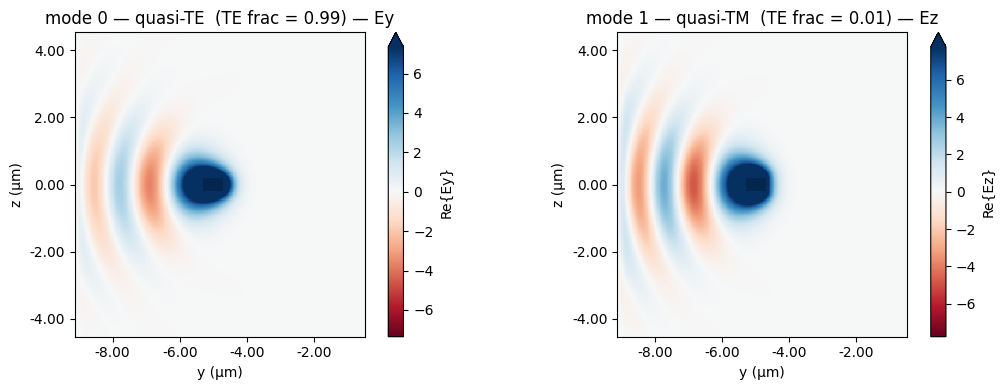

In [7]:
# Side-by-side view of the two most-confined modes (mode_index = 0 and 1).
# TE_fraction tells us which one is quasi-TE (horizontal E in the waveguide
# plane, dominant Ey) and which is quasi-TM (vertical E, dominant Ez).
te_frac = ms_data.TE_fraction.isel(f=0).values  # shape: (num_modes,)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m in zip(axes, [0, 1]):
    label = "quasi-TE" if te_frac[m] > 0.5 else "quasi-TM"
    component = "Ey" if te_frac[m] > 0.5 else "Ez"  # dominant transverse E
    ms.plot_field(component, "real", mode_index=m, ax=ax)
    ax.set_title(f"mode {m} — {label}  (TE frac = {te_frac[m]:.2f}) — {component}")

plt.tight_layout()
plt.show()

In [8]:
mode_index = 0
print("Selected mode index:", mode_index)

Selected mode index: 0


In [9]:
fdtd_sim = build_fdtd_bend(
    radius=radius,
    width=width,
    thickness=thickness,
    num_modes=num_modes,
    target_neff=target_neff,
    freq0=freq0,
    plane_size=plane_size,
    min_steps_per_wvl=min_steps_per_wvl,
    mode_index=mode_index,  # fundamental quasi-TE bend mode
)

fdtd_data = web.run(
    fdtd_sim,
    task_name="bent_LiNbO3_FDTD",
    path="FDTD_GT.hdf5",
)

18:00:52 -03 Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=705601;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=181624;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\taskId]8;;\]8;id=705601;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\=]8;;\]8;id=513700;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\fdve]8;;\]8;id=705601;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\-a0b96ad7-6e3]8;;\
             ]8;id=705601;https://tidy3d.simulation.cloud/workbench?taskId=fdve-a0b96ad7-6e35-492d-8a16-05f1193e3124\5-492d-8a16-05f1193e3124']8;;\.

FDTD transmittance: T = 0.4948  (-3.06 dB)


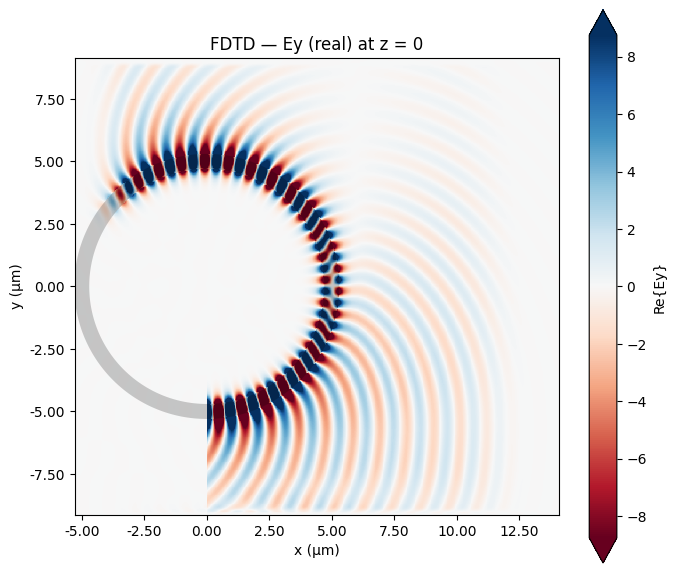

In [10]:
# Transmittance into the fundamental guided mode at the output (|S21(0,0)|²).
amps_out = fdtd_data["mode_out"].amps.sel(direction="-")
T_fdtd = float(np.abs(amps_out.isel(f=0, mode_index=mode_index)) ** 2)
print(f"FDTD transmittance: T = {T_fdtd:.4f}  ({10 * np.log10(T_fdtd):.2f} dB)")

# Field plot
fig, ax = plt.subplots(figsize=(7, 6))
fdtd_data.plot_field("field_xy", "Ey", "real", ax=ax)
ax.set_title("FDTD — Ey (real) at z = 0")
plt.tight_layout()
plt.show()

## Step 2 — EME Convergence Study

### EME Setup for a Bent Waveguide

In Tidy3D's [EMESimulation](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMESimulation.html), a bent waveguide is modelled as a **straight** simulation box whose length matches the bend arc length ($L = \pi r$ for a 180° bend). In each EME cell, `bend_radius` is specified in [EMEModeSpec](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEModeSpec.html)to compute the correct curved eigenmodes via conformal mapping (bend boundary conditions). We set `precision="double"` because, in single precision, the near-degenerate quasi-TE and quasi-TM modes of this anisotropic bend can be mis-sorted, which affects the convergence. The longitudinal discretization is controlled by [EMEUniformGrid](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEUniformGrid.html).

When the waveguide medium is **isotropic**, the curved eigenmodes are the same regardless of where along the arc the cross-section is taken — one EME cell is sufficient.

When the medium is **anisotropic** (LiNbO₃), the lab-frame permittivity tensor projects differently onto the local propagation frame at each position $\phi$ along the arc. Dividing the bend into $N$ cells with independently computed eigenmodes causes $N-1$ inter-cell interfaces at which mode-matching generates back-reflected amplitudes.

> **On `bend_medium_frame`.** This example relies on `bend_medium_frame="global"` — the default in `EMEModeSpec` since Tidy3D **2.11** — which keeps the LiNbO₃ crystal axes fixed in physical space, the same convention as FDTD. Before this option existed (and as in many other EME solvers) the effective behavior was `"co_rotating"`, where the medium bends together with the local cross-section; in that frame the tensor is identical in every cell, so you would obtain the single-cell ($N=1$) result regardless of the number of cells, and the convergence effect studied here would not appear.

### Expected Behavior

- **$N = 1$**: No interfaces → no back-scattering from tensor rotation → **overestimated transmission**.
- **Increasing $N$**: Each added interface captures more of the physical mode conversion → transmission moves toward the FDTD reference.
- **Large $N$**: EME converges toward FDTD. Note that a piecewise-constant EME approximation to a *smoothly* rotating anisotropic tensor is not guaranteed to make $|S_{00}|^2$ decrease strictly monotonically — modal truncation and mode reordering/conversion can produce small non-monotonic wiggles. Convergence is therefore best judged with a mode-count sweep and the interface residual diagnostics (below), rather than by strict monotonicity of $|S_{00}|^2$ alone.

We sweep $N \in \{1, 2, 3, 4, 5\}$ and compare with $T_\text{FDTD}$.

In [11]:
def build_eme_bend(fdtd_sim, num_cells):
    """Build an EME bend simulation derived from an existing FDTD simulation.

    All parameters (radius, width, thickness, num_modes, target_neff, freq0,
    plane size, and materials) are extracted from fdtd_sim, guaranteeing that
    both simulations model the exact same structure.

    Parameters
    ----------
    fdtd_sim : td.Simulation
        The FDTD bend simulation returned by build_fdtd_bend().
    num_cells : int
        Number of uniform EME cells to divide the 180-degree arc into.
    """
    src = fdtd_sim.sources[0]
    ring_geom = fdtd_sim.structures[0].geometry  # ClipOperation: outer - inner

    # ── Extract all parameters from the FDTD simulation ────────────────────
    freq0 = src.source_time.freq0
    num_modes = src.mode_spec.num_modes
    target_neff = src.mode_spec.target_neff
    radius = abs(src.mode_spec.bend_radius)  # stored as negative in the source
    plane_size = (src.size[1], src.size[2])
    num_pml = src.mode_spec.num_pml
    grid_spec = fdtd_sim.grid_spec

    core_medium = fdtd_sim.structures[0].medium
    background_medium = fdtd_sim.medium

    # Width and thickness from the ring geometry (outer Cylinder - inner Cylinder)
    outer_cyl = ring_geom.geometry_a
    inner_cyl = ring_geom.geometry_b
    width = outer_cyl.radius - inner_cyl.radius
    thickness = outer_cyl.length
    # ───────────────────────────────────────────────────────────────────────

    arc_length = np.pi * radius  # 180-degree arc

    # Sort modes by fill_fraction_box so the well-confined guided mode sits at
    # index 0 at every EME cell boundary. Each cell boundary is a plane normal
    # to x at a different x, so the bounding_box needs to span all of them —
    # use td.inf along x (core centred at y = 0, z = 0 since the EME models a
    # straight waveguide with curvature encoded in bend_radius).
    core_box_eme = td.Box(center=(0, 0, 0), size=(td.inf, width, thickness))
    mode_spec = td.EMEModeSpec(
        num_modes=num_modes,
        target_neff=target_neff,
        bend_radius=radius,
        bend_axis=1,
        num_pml=num_pml,
        increasing_mode_tolerance=1e-3,
        sort_spec=td.ModeSortSpec(sort_key="fill_fraction_box", bounding_box=core_box_eme),
        precision="double",
    )

    # Infinite straight waveguide slab (curvature fully encoded in mode_spec)
    wg = td.Structure(
        geometry=td.PolySlab(
            axis=2,
            slab_bounds=(-thickness / 2, thickness / 2),
            vertices=[
                [-1e15, -width / 2],
                [-1e15, width / 2],
                [1e15, width / 2],
                [1e15, -width / 2],
            ],
        ),
        medium=core_medium,
    )

    return td.EMESimulation(
        size=(arc_length, plane_size[0], plane_size[1]),
        center=(0, 0, 0),
        structures=[wg],
        medium=background_medium,
        axis=0,
        freqs=[freq0],
        eme_grid_spec=td.EMEUniformGrid(num_cells=num_cells, mode_spec=mode_spec),
        grid_spec=grid_spec,
    )

In [12]:
num_cells_list = [1, 2, 3, 4, 5]

eme_sims = [build_eme_bend(fdtd_sim, num_cells=n) for n in num_cells_list]

eme_batch = {f"bent_LiNbO3_EME_N{n:02d}": sim for n, sim in zip(num_cells_list, eme_sims)}
eme_results = web.run(eme_batch)

eme_data_list = [eme_results[f"bent_LiNbO3_EME_N{n:02d}"] for n in num_cells_list]

18:00:54 -03 Found all simulations in cache.

In [13]:
# S00 is the fundamental-to-fundamental transmission. fill_fraction_box sorts the
# most core-confined mode to index 0, but not by polarization — so here we also
# confirm the index-0 port mode is the quasi-TE fundamental: effective index
# n_eff ~ 1.65 and TE fraction ~ 1, i.e. S00 really is the quasi-TE -> quasi-TE
# channel. (A per-cell check follows below.)
T_eme = []
for n, eme_data in zip(num_cells_list, eme_data_list):
    T = float(eme_data.smatrix.S21.isel(mode_index_in=0, mode_index_out=0, f=0).abs.item() ** 2)
    # Effective index and TE fraction of the index-0 port mode (n_eff averaged
    # over the 2 ports; TE fraction = |Ey|^2 / (|Ey|^2 + |Ez|^2), worst of the 2).
    pm = eme_data.port_modes
    neff0 = float(pm.n_complex.real.isel(mode_index=0).mean().values)
    Ey2 = (abs(pm.Ey) ** 2).sum(("x", "y", "z"))
    Ez2 = (abs(pm.Ez) ** 2).sum(("x", "y", "z"))
    te0 = float((Ey2 / (Ey2 + Ez2)).real.isel(mode_index=0).min().values)
    print(
        f"  N = {n:2d} cells  \u2192  T = {T:.4f}  ({10 * np.log10(T):.2f} dB)   |  mode-0: n_eff \u2248 {neff0:.4f}, TE fraction \u2265 {te0:.3f}"
    )
    T_eme.append(T)

  N =  1 cells  →  T = 0.6123  (-2.13 dB)   |  mode-0: n_eff ≈ 1.6835, TE fraction ≥ 0.984
  N =  2 cells  →  T = 0.5108  (-2.92 dB)   |  mode-0: n_eff ≈ 1.6661, TE fraction ≥ 0.986
  N =  3 cells  →  T = 0.5023  (-2.99 dB)   |  mode-0: n_eff ≈ 1.6572, TE fraction ≥ 0.987
  N =  4 cells  →  T = 0.5016  (-3.00 dB)   |  mode-0: n_eff ≈ 1.6535, TE fraction ≥ 0.987
  N =  5 cells  →  T = 0.5017  (-3.00 dB)   |  mode-0: n_eff ≈ 1.6517, TE fraction ≥ 0.987


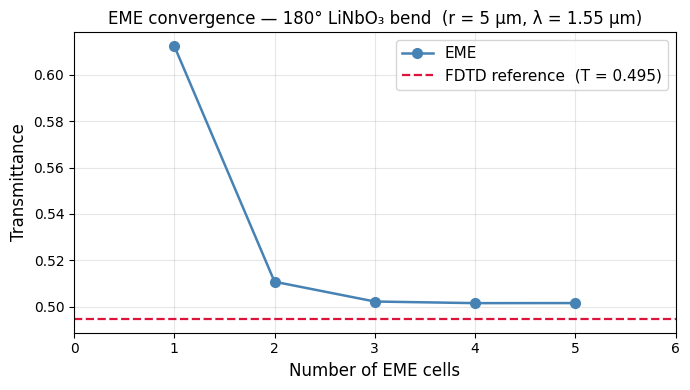


N=1   overestimates by  23.8%
N=4 error vs FDTD:    1.4%
N=5 error vs FDTD:    1.4%


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    num_cells_list,
    T_eme,
    "o-",
    color="steelblue",
    linewidth=1.8,
    markersize=7,
    label="EME",
)
ax.axhline(
    T_fdtd,
    color="crimson",
    linestyle="--",
    linewidth=1.6,
    label=f"FDTD reference  (T = {T_fdtd:.3f})",
)

ax.set_xlabel("Number of EME cells", fontsize=12)
ax.set_ylabel("Transmittance", fontsize=12)
ax.set_title("EME convergence — 180° LiNbO₃ bend  (r = 5 µm, λ = 1.55 µm)", fontsize=12)
ax.legend(fontsize=11)

ax.set_xlim(0, max(num_cells_list) + 1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nN={num_cells_list[0]}   overestimates by  {(T_eme[0] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-2]} error vs FDTD:    {abs(T_eme[-2] - T_fdtd) / T_fdtd * 100:.1f}%")
print(f"N={num_cells_list[-1]} error vs FDTD:    {abs(T_eme[-1] - T_fdtd) / T_fdtd * 100:.1f}%")

## Discussion

### Behavior with Cell Count

The plot shows three regimes:

| Region | Cells | Observation |
|--------|-------|-------------|
| **Single-cell** | $N = 1$ | T ≈ 0.61 — large overestimate (~24% above FDTD). |
| **Transition** | $N = 2$ | T drops sharply as the dominant back-reflection is captured. |
| **Stable** | $N \geq 3$ | T ≈ 0.50, approaching FDTD to within ~2%. |

### Why One Cell Is Not Enough

With a single EME cell the solver computes one set of curved eigenmodes for the entire 180° arc, assuming a fixed tensor orientation. At the ports, these modes are matched to straight-waveguide modes. With no internal interfaces, the system behaves close to a lossless propagator.

In reality, the eigenmodes evolve continuously as the tensor rotates. Splitting the arc into $N$ cells approximates this as discrete steps. At each step, modes are reprojected onto a new basis, introducing reflections and mode mismatch. Increasing $N$ improves this approximation.

## Convergence Diagnostics (N = 5 cells)

The cell-count curve is only meaningful if, at each cell count, the result is already converged in the **number of expansion modes**, and if the mode tracked at index 0 is really the intended quasi-TE fundamental. For the converged `N = 5` case we therefore:

1. **sweep the number of modes** with [`EMEModeSweep`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEModeSweep.html) (free; the modes are solved once and reused);
2. inspect the **mode identity** (effective index and TE fraction) at every cell, recorded with an [`EMEModeSolverMonitor`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.EMEModeSolverMonitor.html);
3. check the **interface field residual** from `eme_diagnostics` as a convergence criterion.

### What `eme_diagnostics` reports

EME builds the scattering matrix by enforcing continuity of the tangential **E** and **H** fields at every cell interface, expressed in a *truncated* set of modes. If that basis is too small, the matched fields do not quite agree across the interface, so the leftover mismatch is the **interface residual**. Setting `eme_diagnostics=True` makes the solver compute and store, per interface and per swept mode count:

- `normalized_tangential_E_residual` / `normalized_tangential_H_residual` — the incident-normalized squared tangential-field mismatch over the whole cross-section;
- `normalized_aperture_tangential_E_residual` / `normalized_aperture_tangential_H_residual` — the same, but restricted to the **physical aperture, excluding the PML**, so the metric is not masked by PML absorption;
- `power_defect` — the violation of power conservation at the interface.

A well-converged expansion reproduces the interface fields almost exactly, so the residual **decreases toward zero (and plateaus) as modes are added**. This is a direct, *physical* convergence check: unlike $|S_{00}|^2$, it does not require strict monotonicity and is not fooled by mode reordering. Below we plot the non-PML tangential-E residual of the **incident fundamental mode** (worst case over interfaces and ports) versus the mode count. (High-order radiative / PML-like modes are barely represented by the truncated basis, so their interface residual is intrinsically large and would dominate a max over all modes; they carry no guided power, so the fundamental — the channel we launch and measure — is the meaningful one to track.)

(`eme_diagnostics` requires Tidy3D ≥ 2.12.)

In [15]:
# Reuse the converged 5-cell EME, but for this mode-count study bump the solved
# basis to 20 modes (via the EMEModeSpec), and add a per-cell mode-solver monitor
# and interface-residual diagnostics.
eme_5 = eme_sims[num_cells_list.index(5)]
mode_sweep = [4, 6, 8, 10, 12, 15, 20]

mode_spec_20 = eme_5.eme_grid_spec.mode_spec.updated_copy(num_modes=20)
mode_monitor = td.EMEModeSolverMonitor(
    name="modes",
    size=(td.inf, td.inf, td.inf),
    center=(0, 0, 0),
    num_modes=6,
    eme_cell_interval_space=1,
)
eme_5_diag = eme_5.updated_copy(
    eme_grid_spec=eme_5.eme_grid_spec.updated_copy(mode_spec=mode_spec_20),
    sweep_spec=td.EMEModeSweep(num_modes=mode_sweep),
    monitors=[mode_monitor],
    eme_diagnostics=True,
)
eme_5_data = web.run(eme_5_diag, task_name="bent_LiNbO3_EME_N05_diag")

18:00:59 -03 Created task 'bent_LiNbO3_EME_N05_diag' with resource_id           
             'eme-d1c100d4-f22e-4055-8d51-e0260961ce04' and task_type 'EME'.

             Tidy3D's EME solver is currently in the beta stage. Cost of EME    
             simulations is subject to change in the future.

Output()

18:01:04 -03 Estimated FlexCredit cost: 0.172. Minimum cost depends on task     
             execution details. Use 'web.real_cost(task_id)' to get the billed  
             FlexCredit cost after a simulation run.

18:01:06 -03 status = success

Output()

18:01:30 -03 Loading results from simulation_data.hdf5

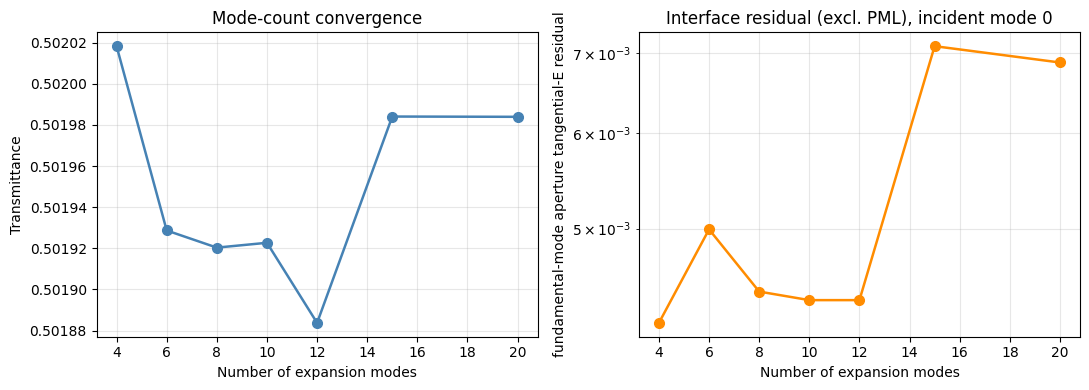

In [16]:
T_modes = [
    float(
        eme_5_data.smatrix.S21.isel(
            sweep_index=i, mode_index_in=0, mode_index_out=0, f=0
        ).abs.item()
        ** 2
    )
    for i in range(len(mode_sweep))
]

residual = eme_5_data.diagnostics.interface_residuals.normalized_aperture_tangential_E_residual
reduce_dims = [d for d in residual.dims if d not in ("sweep_index", "mode_index")]
residual_fund = (
    residual.isel(mode_index=0).max(dim=reduce_dims).values.ravel()
)  # worst over interfaces/ports

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(mode_sweep, T_modes, "o-", color="steelblue", linewidth=1.8, markersize=7)
ax1.set_xlabel("Number of expansion modes")
ax1.set_ylabel("Transmittance")
ax1.set_title("Mode-count convergence")
ax1.grid(True, alpha=0.3)

ax2.semilogy(mode_sweep, residual_fund, "o-", color="darkorange", linewidth=1.8, markersize=7)
ax2.set_xlabel("Number of expansion modes")
ax2.set_ylabel("fundamental-mode aperture tangential-E residual")
ax2.set_title("Interface residual (excl. PML), incident mode 0")
ax2.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

                                          n_eff  TE_fraction
f            sweep_index eme_cell_index                     
1.934145e+14 0           0               1.6517       0.9877
                         1               1.6715       0.9855
                         2               1.6835       0.9845
                         3               1.6716       0.9852
                         4               1.6517       0.9874


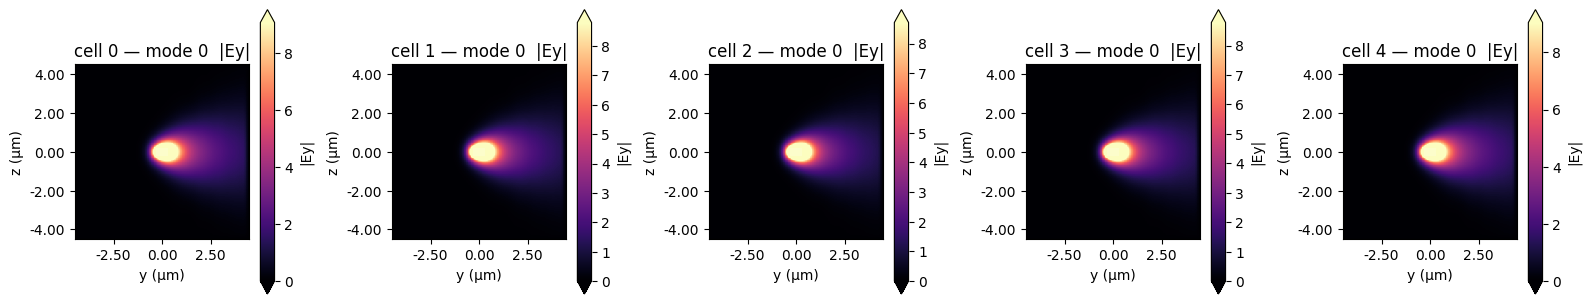

In [17]:
# Mode identity: effective index and TE fraction of the index-0 mode at every cell.
# Index 0 should be the quasi-TE fundamental (TE fraction ~ 1) at every cell.
modes = eme_5_data["modes"]
n_eff = modes.n_complex.real
Ey2 = (abs(modes.Ey) ** 2).sum(("x", "y", "z"))
Ez2 = (abs(modes.Ez) ** 2).sum(("x", "y", "z"))
te_fraction = (Ey2 / (Ey2 + Ez2)).real  # |Ey|² / (|Ey|² + |Ez|²)
identity = n_eff.to_dataframe(name="n_eff").join(te_fraction.to_dataframe(name="TE_fraction"))
print(identity.xs(0, level="mode_index").round(4).to_string())

# Fundamental mode (index 0), |Ey|, across the 5 cells.
fig, axes = plt.subplots(1, 5, figsize=(16, 3.2))
for cell_index, ax in enumerate(axes):
    eme_5_data.plot_field("modes", "Ey", val="abs", eme_cell_index=cell_index, mode_index=0, ax=ax)
    ax.set_title(f"cell {cell_index} — mode 0  |Ey|")
plt.tight_layout()
plt.show()

### Convergence Verdict

Both the transmittance and the interface residual are already flat by ~4–6 modes (residual $\sim 5\times10^{-3}$) and mode 0 stays the quasi-TE fundamental (TE fraction $\approx 0.99$) at every cell, so `num_modes = 5` is sufficient and the EME plateau (~2% above FDTD) is a converged result, judged by the interface residual rather than by strict monotonicity of $|S_{00}|^2$.